## Purpose of the Interactive Notebook

The `TOAD_Amazon_interactive.ipynb` is an interactive sandbox that allows you to:
- **Select different models and variables** and see results immediately
- **Tune TOAD parameters** (shift detection, clustering) while observing the effects
- **Explore the TOAD pipeline** step-by-step for learning and debugging

### Quick Start Guide

**Step 1: Choose a variable**
```python
MODEL = "TaiESM1"
VARIABLE = "cVeg"  # Options: cVeg, MCWD, fFire, grassFrac, treeFrac, AnnualRainfall
ROLLING_YEARS = 1  # Options: 1 (annual), 5 (5-year smooth), 10 (10-year smooth)
```

**Step 2: Load and explore data**
- Run Cells to load the preprocessed .nc file
- View preprocessing results: trend plot and spatial distribution

**Step 3: Detect shifts**
- Adjust `window_indices`, `min_abs_change`, `min_rel_change` to tune sensitivity

**Step 4: Cluster shifts**
- Run Cells for basic clustering with fixed parameters
- Run Cells for optimized clustering 

In [ ]:
# Prerequisites
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import sys
import os
from pathlib import Path

# Automatically find Amazon/ directory regardless of where notebook is opened from
current_dir = Path.cwd()
if current_dir.name == "docs":
    amazon_dir = current_dir.parent
else:
    # Search for Amazon directory up the tree
    amazon_dir = current_dir
    while amazon_dir.name != "Amazon" and amazon_dir.parent != amazon_dir:
        amazon_dir = amazon_dir.parent
    if amazon_dir.name != "Amazon":
        amazon_dir = current_dir / ".." / "Amazon"

amazon_dir = amazon_dir.resolve()
print(f"Working from Amazon directory: {amazon_dir}")

# Ensure Amazon directory is in sys.path for imports
if str(amazon_dir) not in sys.path:
    sys.path.insert(0, str(amazon_dir))

### 1. Load preprocessed model data
When you change the model and variable, you can see different result automatically!

In [ ]:
MODEL = "TaiESM1"
VARIABLE = "MCWD"
ROLLING_YEARS = 1
# ROLLING_YEARS = 1   # annual
# ROLLING_YEARS = 5    # 5-year centered rolling mean
# ROLLING_YEARS = 10   # 10-year centered rolling mean

def smoothing_suffix(rolling_years=None):
    if rolling_years is None or rolling_years <= 1:
        return ""
    return f"_smooth{rolling_years}yr"


def get_plot_path(plot_type, model_name, variable, rolling_years=None):
    suffix = smoothing_suffix(rolling_years)

    filename_map = {
        "trend": f"TrendPlot_{variable}_{model_name}{suffix}.png",
        "spatial": f"SpatialMap_{variable}_{model_name}{suffix}.png",
    }

    return amazon_dir / "plots" / model_name / filename_map[plot_type]

suffix = smoothing_suffix(ROLLING_YEARS)

# Use absolute paths
file_path = amazon_dir / f"processed_data/{MODEL}/TOAD_{VARIABLE}_{MODEL}{suffix}.nc"
print(f"Loading: {file_path}")

In [7]:
# Open the processed dataset(netCDF)
ds = xr.open_dataset(file_path)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/processed_data/TaiESM1/TOAD_MCWD_TaiESM1.nc'

#### check resolution of model output

In [ ]:
print("source_id:", ds.attrs.get("source_id"))
print("experiment_id:", ds.attrs.get("experiment_id"))
print("variant_label:", ds.attrs.get("variant_label"))
print("First time:", ds["time"].values[0])
print("Last time:", ds["time"].values[-1])
nominal_res = ds.attrs.get("nominal_resolution", "Not Available")
print("Spatial resolution:", f"Nominal Resolution: {nominal_res}")

source_id: TaiESM1
experiment_id: 1pctCO2
variant_label: r1i1p1f1
First time: 0001-01-01 00:00:00
Last time: 0150-01-01 00:00:00
Spatial resolution: Nominal Resolution: 100 km


Annual average, with GWL dataset : `Variable you chose` : (GWL, lat, lon)

this data have annual average of variable in each grid in Amazon area.

#### Plot and check data

##### (1) Average Trend of Variable in all amazon area

In [ ]:
from IPython.display import Image, display

trend_path = amazon_dir / f"plots/{MODEL}/TrendPlot_{VARIABLE}_{MODEL}{suffix}.png"

# show image
display(Image(filename=str(trend_path)))

##### (2) Spatial Distribution by different Global Warming Level

In [ ]:
spatial_path = amazon_dir / f"plots/{MODEL}/SpatialMap_{VARIABLE}_{MODEL}{suffix}.png"

# show image
display(Image(filename=str(spatial_path)))

### Start TOAD

In [ ]:
import sys
import os

# Add Amazon directory to path (already done in prerequisites)
from toad import TOAD

td = TOAD(ds, time_dim="GWL")

### Step 1: Compute shifts


In [ ]:
import sys
import os

# Add Amazon directory to path (already set up in prerequisites)
from custom_shift_method import FilteredASDETECT

# the test data already contains computed shifts, so let's just drop them
td.drop_shifts()

cveg_method = FilteredASDETECT(
    window_indices=15,       # 15 years before and after
    min_abs_change=2.0,      # at least 2 kgC/m2 absolute change
    min_rel_change=0.25      # at least 25% relative change
)

# define variable and method
td.compute_shifts(var=VARIABLE, method=cveg_method)
# ~3m 15s

### Show all detected abrupt shifts

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'Maximum shift magnitude for cVeg'}, xlabel='Longitude [degrees_east]', ylabel='Latitude [degrees_north]'>)

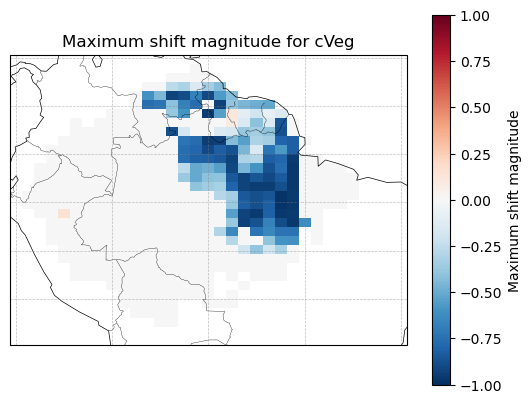

In [ ]:
td.plot.max_shift_map()

##### Show shifts satisfying `shift_magnitude_threshold` and `shift_direction`

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'Time of maximum shift for cVeg'}, xlabel='Longitude [degrees_east]', ylabel='Latitude [degrees_north]'>)

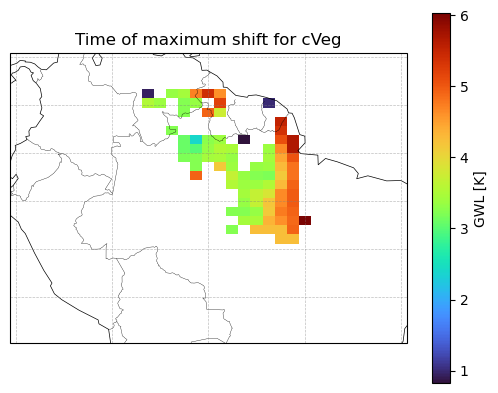

In [ ]:
td.plot.time_of_max_shift_map(shift_direction="negative", shift_threshold=0.5)
# where abs(shift) > shift_threshold.

#### Check the single grid - detected series

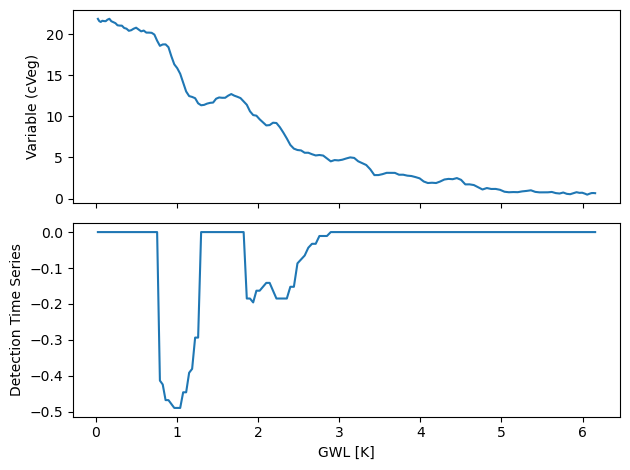

In [ ]:
fig, axs = plt.subplots(2, sharex=True)
target_lon = 305.0  # e.g., 300°E
target_lat = 5.0   # e.g., 5°S

td.data[VARIABLE].sel(lon=target_lon, lat=target_lat, method="nearest").plot(ax=axs[0])
td.data[f"{VARIABLE}_dts"].sel(lon=target_lon, lat=target_lat, method="nearest").plot(ax=axs[1])

axs[0].set_ylabel(f"Variable ({VARIABLE})")
axs[1].set_ylabel("Detection Time Series")
axs[0].set_title("")
axs[1].set_title("")
axs[0].set_xlabel("")
fig.tight_layout()

### Clustering-Single(not optmized)

Basically, all clustering apply filter : `DEFAULT_SHIFT_THRESHOLD`: float = 0.5.

it means, only filter detected shifts whose absolute magnitude are larger than 0.5

In [ ]:
from toad.clustering.methods.space_time_dbscan import SpaceTimeDBSCAN
td.data = td.data.drop_vars(td.cluster_vars)

td.compute_clusters(
    method=SpaceTimeDBSCAN(
        spatial_eps=1000,  # km 
        temporal_eps=0.3,  # units of the time variable -> our time steps is 'GWL" degree 
        min_samples=10 # 15~55
    ),
    shift_direction='negative' # This filter only "decreasing" abrupt shift.
)

INFO: New cluster variable cVeg_dts_cluster: Identified 3 clusters in 93 pts; Left 18.3% as noise (17 pts).


**Space-Time-DBSCAN parameter**
- **spatial_eps**: (km) How far can you tell it is the similar abrupt shift pattern? 
if one grid where away from 500km, have abrupt shift in the same time with another grid, Can you tell it would be in the same cluster?
our grid resolution is 250km, so if we set this 500km, it covers 2 grid length together.

- **temporal_eps** : (time_unit you set) We seeing vegetation carbon data per each Global warming level - and we have the annual vegetation carbon data, so our unit of time is "GWL(time)/year" 
Which time step can you tell it is close? at different grids, it show abrupt shifts after 1 year, one showed to the another. Can we say that it should be in the same cluster?

1. spatial_eps: [300.0, 1000.0]
Unit: Kilometers (km)

Operational Criteria: The maximum physical distance allowed for two grid cells to be grouped into the same cluster.

Range Interpretation:

The spatial resolution of typical CMIP6 climate models is 1 to 2 degrees (approximately 100 to 250 km).

Lower bound 300.0 km: Grants spatial adjacency spanning at least 2 to 3 grid cells. This indicates an intent to identify 'regional' patterns rather than immediate pixel-level grouping.

Upper bound 1000.0 km: Connects grid cells within the Amazon basin up to 1000 km apart if their shift timings align. This serves as a baseline to evaluate whether vegetation collapse manifests as a macroscopic synchronization.

2. temporal_eps: [0.1, 0.8]
Unit: Global Warming Level (GWL, Kelvin)

Operational Criteria: The maximum timing (temperature) difference allowed for two grid cells to be grouped into the same cluster.

Range Interpretation:

Lower bound 0.1 K: Requires shift timings to match within a 0.1-degree margin. This imposes strict simultaneity, identifying regions that collapse at a single temperature tipping point.

Upper bound 0.8 K: Groups grid cells that collapse sequentially over a 0.8-degree warming period. This condition encompasses cascading tipping phenomena, where a collapse in one region induces moisture stress and spreads to adjacent areas.

3. min_samples: [9, 50]
Unit: Number of grid cells

Operational Criteria: The minimum number of grid cells required to formally recognize grouped data points as an independent cluster.

Range Interpretation:

Lower bound 9: Discards scattered changes occurring in 1 to 8 grid cells as noise (gray X markers), even if they passed the 2nd-tier filter. Requires the simultaneous collapse of at least 9 grid cells to be considered an ecologically significant regime shift.

Upper bound 50: Sets a minimum threshold of 50 grid cells for a large-scale cluster. This operates as a baseline to detect massive, sub-biome scale destruction rather than localized events.


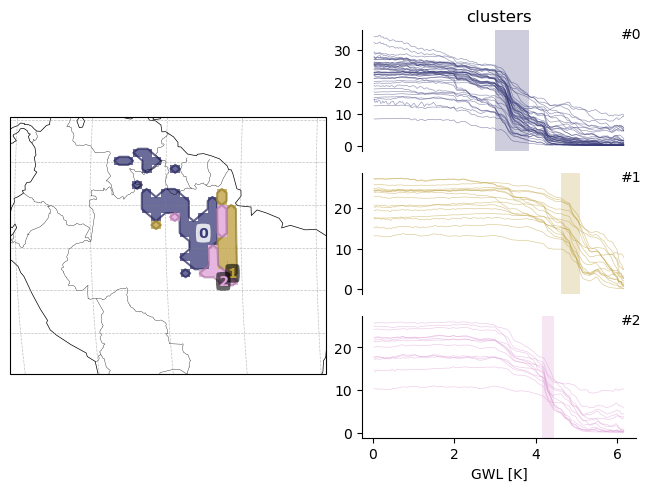

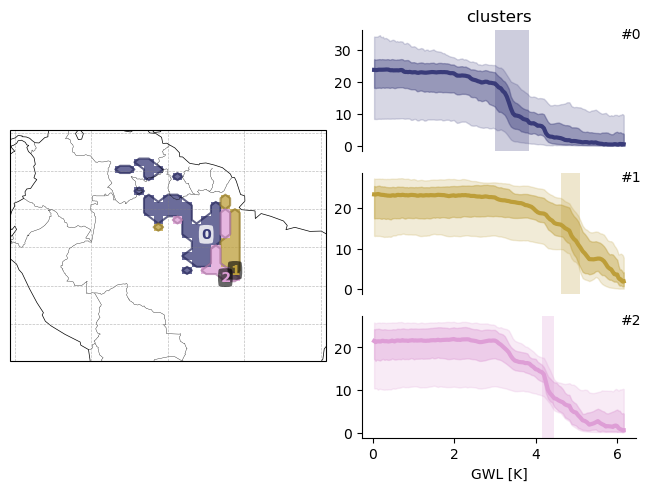

In [ ]:
td.plot.overview(map_style={"projection": "global"});
td.plot.overview(mode="aggregated");

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from matplotlib.cm import get_cmap


def plot_3d_spatiotemporal_clusters(
    td,
    var="cVeg",
    shift_direction="negative",
    view_angle=(30, -60),
    shapefile_path=None,
):

    # ---------------------------------------------------
    # Extract TOAD results
    # ---------------------------------------------------

    transition_time = td.stats(var).time.compute_transition_time(
        shift_direction=shift_direction
    )

    clusters_3d = td.get_clusters(var)
    clusters_2d = clusters_3d.max(dim=td.time_dim)

    lons, lats = np.meshgrid(
        transition_time.lon.values,
        transition_time.lat.values,
    )

    gwl_vals = transition_time.values.flatten()
    lon_vals = lons.flatten()
    lat_vals = lats.flatten()
    cluster_vals = clusters_2d.values.flatten()

    # Convert longitude from 0–360 to -180–180
    lon_vals = np.where(lon_vals > 180, lon_vals - 360, lon_vals)

    valid_mask = ~np.isnan(gwl_vals)

    gwl_valid = gwl_vals[valid_mask]
    lon_valid = lon_vals[valid_mask]
    lat_valid = lat_vals[valid_mask]
    cluster_valid = cluster_vals[valid_mask]

    # ---------------------------------------------------
    # Figure
    # ---------------------------------------------------

    fig = plt.figure(figsize=(14, 11))
    ax = fig.add_subplot(111, projection="3d")

    cmap = get_cmap("tab10")

    # ---------------------------------------------------
    # Determine floor height
    # ---------------------------------------------------

    z_floor = np.nanmin(gwl_valid) - 0.2

    # ---------------------------------------------------
    # Plot faint projection on floor
    # ---------------------------------------------------

    ax.scatter(
        lon_valid,
        lat_valid,
        np.full_like(gwl_valid, z_floor),
        c="lightgray",
        s=6,
        alpha=0.15,
        depthshade=False,
    )

    # ---------------------------------------------------
    # Noise
    # ---------------------------------------------------

    noise_mask = (cluster_valid == -1) | np.isnan(cluster_valid)

    ax.scatter(
        lon_valid[noise_mask],
        lat_valid[noise_mask],
        gwl_valid[noise_mask],
        c="gray",
        s=70,
        alpha=0.5,
        depthshade=False,
        label="Unclustered (Noise)",
    )

    # ---------------------------------------------------
    # Clusters
    # ---------------------------------------------------

    unique_clusters = np.unique(cluster_valid[~noise_mask])

    for i, cid in enumerate(unique_clusters):

        mask = cluster_valid == cid

        ax.scatter(
            lon_valid[mask],
            lat_valid[mask],
            gwl_valid[mask],
            color=cmap(i % 10),
            s=70,
            edgecolor="black",
            linewidth=0.4,
            alpha=0.95,
            depthshade=False,
            label=f"Cluster #{int(cid)}",
        )

    # ---------------------------------------------------
    # Amazon boundary
    # ---------------------------------------------------

    if shapefile_path is not None:

        amazon = gpd.read_file(shapefile_path)

        if "bioma" in amazon.columns:
            amazon = amazon[amazon["bioma"] == "Amazonía"]

        for geom in amazon.geometry:

            polygons = [geom] if geom.geom_type == "Polygon" else geom.geoms

            for poly in polygons:

                x, y = poly.exterior.xy

                x = np.asarray(x)
                y = np.asarray(y)

                x = np.where(x > 180, x - 360, x)

                ax.plot(
                    x,
                    y,
                    zs=z_floor,
                    color="black",
                    linewidth=1.5,
                    alpha=0.8,
                )

    # ---------------------------------------------------
    # Axis settings
    # ---------------------------------------------------

    ax.set_xlim(-82, -45)
    ax.set_ylim(-20, 10)

    ax.set_zlim(
        np.nanmin(gwl_valid) - 0.2,
        np.nanmax(gwl_valid) + 0.2,
    )

    # Make the box visually balanced
    ax.set_box_aspect((1.35, 1.0, 1.1))

    ax.set_xlabel("Longitude", fontsize=11, fontweight="bold", labelpad=10)
    ax.set_ylabel("Latitude", fontsize=11, fontweight="bold", labelpad=10)
    ax.set_zlabel("Global Warming Level (K)", fontsize=11, fontweight="bold", labelpad=12)

    ax.set_title(
        f"3D Spatiotemporal Clustering of {var} Abrupt Shifts",
        fontsize=16,
        fontweight="bold",
        pad=18,
    )

    ax.view_init(
        elev=view_angle[0],
        azim=view_angle[1],
    )

    # Light grid
    ax.grid(True, alpha=0.3)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        title="Cluster Groups",
        frameon=True,
    )

    plt.tight_layout()
    plt.show()

In [ ]:
shapefile_path = amazon_dir.parent / "data/Biome/Biomas.shp"
plot_3d_spatiotemporal_clusters(td, var=VARIABLE, shapefile_path=str(shapefile_path))

### Optimized Clustering - with parameter setting

INFO: optimizing 1000 trials with params: {'spatial_eps': (500.0, 2000.0), 'temporal_eps': (0.0, 0.5), 'min_samples': (9, 50)}


  0%|          | 0/1000 [00:00<?, ?it/s]

INFO: Ran 1000 trials in 91.07 seconds. Best (#102): score 1.0905, params {'spatial_eps': 603.6160896931339, 'temporal_eps': 0.22793484646546747, 'min_samples': 9}. 
INFO: New cluster variable cVeg_dts_cluster: Identified 3 clusters in 93 pts; Left 31.2% as noise (29 pts).


(<Figure size 640x480 with 4 Axes>,
 {'map': <GeoAxes: xlabel='Longitude [degrees_east]', ylabel='Latitude [degrees_north]'>,
  'timeseries': [<Axes: title={'center': 'clusters'}>,
   <Axes: >,
   <Axes: xlabel='GWL [K]'>]})

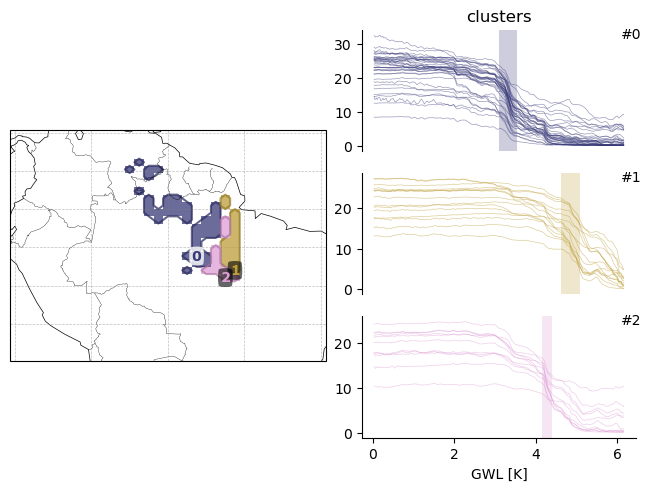

In [ ]:
td.data = td.data.drop_vars(td.cluster_vars)

td.compute_clusters(
    var=VARIABLE,
    method=SpaceTimeDBSCAN,
    shift_direction="negative",
    shift_selection="local",

    optimize=True,
    optimize_params={
        "spatial_eps": (500.0, 2000.0),   # km
        "temporal_eps": (0.0, 0.5),       # °C GWL
        "min_samples": (9, 50),            # integer
    },

    optimize_objective="combined_spatial_nonlinearity",
    optimize_direction="maximize",
    optimize_n_trials=1000,
    overwrite=True,
)

# plot the latest cluster variable
# td.plot.overview(td.cluster_vars[-1], normalize="max_each"); normalisation the y-axis 
td.plot.overview(td.cluster_vars[-1])

In [ ]:
td

In [ ]:
# You can find all method parameters used for the computation in the attributes, e.g:
getattr(td.data, f"{VARIABLE}_dts").attrs

{'standard_name': 'vegetation_carbon_content',
 'long_name': 'Carbon Mass in Vegetation',
 'comment': 'Carbon mass per unit area in vegetation.',
 'units': 'kg m-2',
 'original_name': 'TOTVEGC',
 'cell_methods': 'area: mean where land time: mean',
 'cell_measures': 'area: areacella',
 'history': "2020-02-26T16:13:21Z altered by CMOR: Converted type from 'd' to 'f'.",
 'unit_conversion': 'none',
 'aggregation': 'mean',
 'time_dim': 'GWL',
 'method_name': 'FilteredASDETECT',
 'toad_version': '1.0.8',
 'base_variable': 'cVeg',
 'variable_type': 'shift',
 'shifts_lmin': '5',
 'shifts_min_abs_change': '2.0',
 'shifts_min_rel_change': '0.25',
 'shifts_segmentation': 'two_sided',
 'shifts_window_indices': '15'}

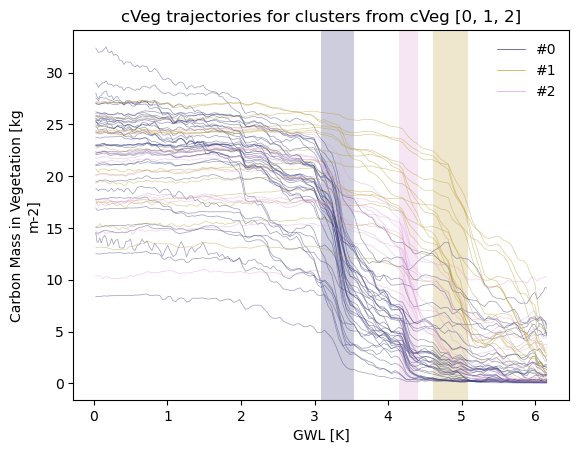

In [ ]:
td.plot.timeseries(cluster_ids=[0, 1, 2]);